In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import math
from scipy.optimize import curve_fit
from scipy.special import erf
import re
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path

In [2]:
filepath = '/Users/taisei/Desktop/ナイフエッジ関係/20260108_vertical_1/power_sweep_data_20260108_125451_ver_up.csv'

In [3]:
re_basename = os.path.splitext(os.path.basename(filepath))[0]
basename_pre = re_basename.replace(' ', '')
basename = basename_pre.replace('power_sweep_data_', '')

print(re_basename)
print(basename_pre)
print(basename)

power_sweep_data_20260108_125451_ver_up
power_sweep_data_20260108_125451_ver_up
20260108_125451_ver_up


In [4]:
df = pd.read_csv(filepath, names = ['position', 'power'], skiprows = 1)
print(pd.concat([df], axis = 1))

    position   power
0      150.0 -23.100
1      300.0 -23.108
2      450.0 -23.099
3      600.0 -23.102
4      750.0 -23.102
5      900.0 -23.106
6     1050.0 -23.102
7     1200.0 -23.101
8     1350.0 -23.097
9     1500.0 -23.076
10    1650.0 -23.042
11    1800.0 -22.968
12    1950.0 -22.822
13    2100.0 -22.569
14    2250.0 -22.209
15    2400.0 -21.760
16    2550.0 -21.262
17    2700.0 -20.757
18    2850.0 -20.293
19    3000.0 -19.892
20    3150.0 -19.578
21    3300.0 -19.356
22    3450.0 -19.208
23    3600.0 -19.121
24    3750.0 -19.079
25    3900.0 -19.056
26    4050.0 -19.046
27    4200.0 -19.039
28    4350.0 -19.037
29    4500.0 -19.030
30    4650.0 -19.030
31    4800.0 -19.027
32    4950.0 -19.024
33    5100.0 -19.020
34    5250.0 -19.018
35    5400.0 -19.017
36    5550.0 -19.013
37    5700.0 -19.012
38    5850.0 -19.007
39    6000.0 -19.008


In [5]:
position = np.array(df['position'])
posi = position*0.02
print(posi)

[  3.   6.   9.  12.  15.  18.  21.  24.  27.  30.  33.  36.  39.  42.
  45.  48.  51.  54.  57.  60.  63.  66.  69.  72.  75.  78.  81.  84.
  87.  90.  93.  96.  99. 102. 105. 108. 111. 114. 117. 120.]


In [6]:
power_dBm = np.array(df['power'])

In [7]:
# dBmをリニア(mW)に変換
power = 10**(power_dBm/10)

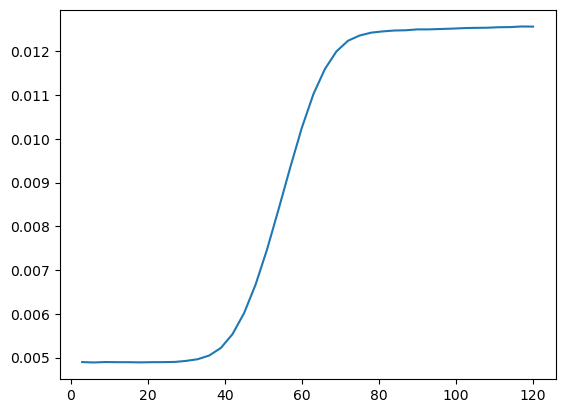

In [8]:
plt.plot(posi, power)

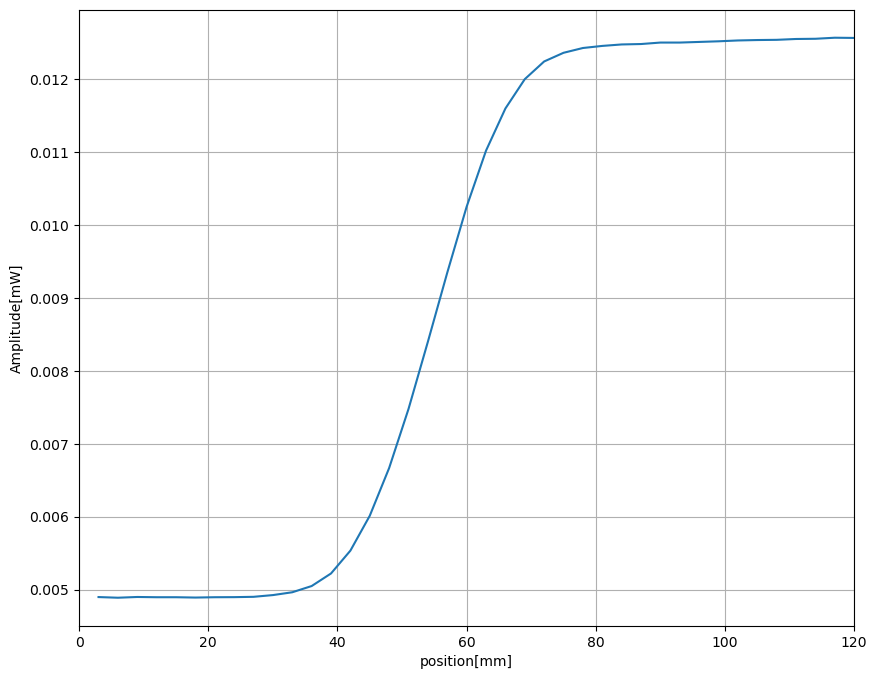

In [9]:
# plt.rcParams['font.size'] = 20
# plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize = (10, 8))

#　グラフを表示
plt.xlabel('position[mm]', fontsize = 10)
plt.ylabel('Amplitude[mW]', fontsize = 10)
# plt.title(basename, fontsize = 10)
plt.grid()
plt.xlim(0, 120)
# plt.ylim(0.000, 0.040)
plt.plot(posi, power)

In [10]:
pi = np.pi

In [11]:
sampling_points = 1000

In [12]:
def quadratic_func(x, a, b, c, d):
    return -(pi*(a**2)/4)*((1+(erf(((np.sqrt(2))*(x-b))/a)))*c)+d

In [13]:
# --- 3. curve_fit を使ってフィッティングを実行 ---
# poptには最適化されたパラメータ[a, b, c]が格納されます
initial_params = [40, 60, 0.01, 0.01] # 警告に表示されたpopt値に近しい値を設定してみる

# 最適化された推定値(popt)と共分散(pcov)の計算
popt, pcov = curve_fit(quadratic_func, posi, power, p0 = initial_params)

# 最適化されたパラメータを画面に表示
print(f"フィッティングによって得られたパラメータ (a, b, c): {popt}")
# print(f"a = {popt[0]:.3f}, b = {popt[1]:.3f}, c = {popt[2]:.3f}")
print('error =', np.sqrt(np.diag(pcov)))
# np.diag(pcov)で行列の対角成分(各パラメータの分散)を取り出し、その平方根を取ることで、各パラメータの標準誤差を計算する。

フィッティングによって得られたパラメータ (a, b, c): [ 1.89435410e+01  5.49524674e+01 -1.35362045e-05  4.89026928e-03]
error = [8.79954760e-02 3.24715442e-02 1.19516036e-07 6.17676878e-06]


In [14]:
# --- 4. 近似曲線用のデータを生成 ---
# 元のx軸データよりも細かい点を生成し、滑らかな曲線を描画する
x_fit = np.linspace(posi.min(), posi.max(), sampling_points)
# 求めたパラメータpoptを使って、対応するy軸の値を計算
# *poptは、配列poptの要素をアンパックしてa, b, cとして関数に渡す記法
y_fit = quadratic_func(x_fit, *popt)

(0.0, 120.0)

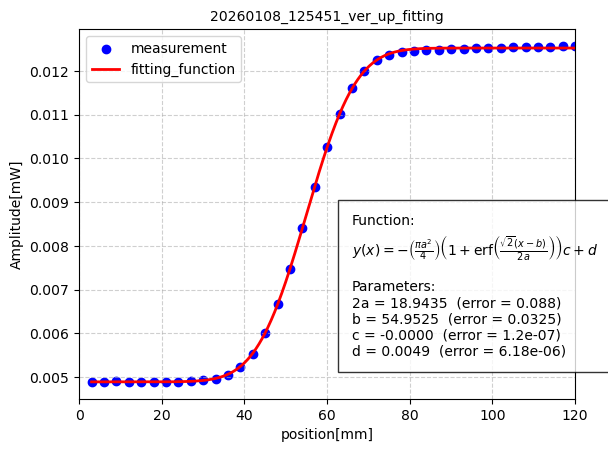

In [15]:
# --- 5. グラフを描画 ---
# グラフのサイズを指定
# plt.figure(figsize = (10, 6))
fig, ax = plt.subplots()

# 元のデータ点を青い点でプロット(散布図)
plt.scatter(posi, power, label = 'measurement', color = 'blue')

# フィットした曲線を赤い線でプロット
plt.plot(x_fit, y_fit, label = 'fitting_function', color = 'red', linewidth = 2)

# グラフのタイトルやラベルを設定
plt.title(basename + '_fitting', fontsize = 10)
plt.xlabel('position[mm]', fontsize = 10)
plt.ylabel('Amplitude[mW]', fontsize = 10)
# ax[0].set_title(basename + '_fitting', fontsize = 15)
# ax[0].set_xlabel('position[mm]', fontsize = 15)
# ax[0].set_ylabel('Amplitude[mW]', fontsize = 15)

# 凡例を表示
plt.legend(fontsize = 10)

# グリッド線を表示
plt.grid(True, linestyle = '--', alpha = 0.6)

formula_latex = r"$y(x) = -\left(\frac{\pi a^2}{4}\right)\left(1+\text{erf}\left(\frac{\sqrt{2}(x-b)}{2 a}\right)\right)c+d$"

param_text = (
    f"2a = {popt[0]:.4f}  (error = {np.sqrt(np.diag(pcov))[0]:.3})\n"
    f"b = {popt[1]:.4f}  (error = {np.sqrt(np.diag(pcov))[1]:.3})\n"
    f"c = {popt[2]:.4f}  (error = {np.sqrt(np.diag(pcov))[2]:.3})\n"
    f"d = {popt[3]:.4f}  (error = {np.sqrt(np.diag(pcov))[3]:.3})"
)

text_box = f"Function:\n{formula_latex}\n\nParameters:\n{param_text}"

# グラフ上の任意の位置にテキストボックスを配置
# transform = ax.transAxesは、座標がグラフの左下(0, 0)から右上(1, 1)の相対座標であることを示す
# bboxはテキストを囲むボックスのスタイル設定
plt.text(
    0.55, # X座標(グラフの右端を1.0とする)
    0.5, # Y座標(グラフの上端を1.0とする)
    text_box,
    transform = ax.transAxes,
    fontsize = 10,
    verticalalignment = 'top',
    bbox = dict(boxstyle = 'square,pad = 1', facecolor = 'white', alpha = 0.8),
)

plt.xlim([0.00, 120.00])
# plt.ylim([0.005, 0.030])

# plt.savefig(f'{basename}_knife_edge_fitting.pdf', bbox_inches = 'tight', format = 'pdf', dpi = 100)

In [16]:
# y_fit[1:]

In [17]:
# x_fit

In [18]:
# 微分の定義
y_dif_list = []
for i in range(sampling_points-1):
    y_dif = (y_fit[i+1]-y_fit[i])/(x_fit[i+1]-x_fit[i])
    y_dif_list.append(y_dif)

In [19]:
print(len(y_dif_list))

999


In [20]:
x_fit_2 = np.linspace(posi.min(), posi.max(), sampling_points-1)

(0.0, 120.0)

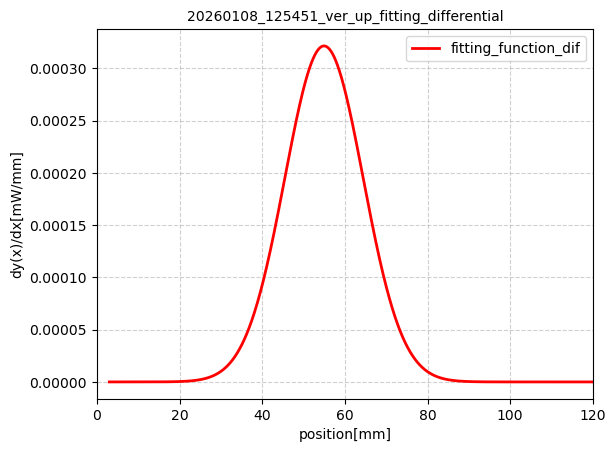

In [21]:
# --- 5. グラフを描画 ---
# グラフのサイズを指定
# plt.figure(figsize = (10, 6))
fig, ax = plt.subplots()

# 元のデータ点を青い点でプロット(散布図)
# plt.scatter(posi, power, label = 'measurement', color = 'blue')

# フィットした曲線を赤い線でプロット
# plt.plot(x_fit_, y_dif_list, label = 'fitting_function_dif', color = 'red', linewidth = 2)
plt.plot(x_fit_2, y_dif_list, label = 'fitting_function_dif', color = 'red', linewidth = 2)

# グラフのタイトルやラベルを設定
plt.title(basename + '_fitting_differential', fontsize = 10)
plt.xlabel('position[mm]', fontsize = 10)
plt.ylabel('dy(x)/dx[mW/mm]', fontsize = 10)
# ax[0].set_title(basename + '_fitting_differential', fontsize = 15)
# ax[0].set_xlabel('position[mm]', fontsize = 15)
# ax[0].set_ylabel('dp/dx', fontsize = 15)

# 凡例を表示
# plt.legend()
plt.legend(fontsize = 10)

# グリッド線を表示
# plt.grid(True, linestyle = '--', alpha = 0.6)
plt.grid(True, linestyle = '--', alpha = 0.6)

# plt.xlim([0.00, 120.00])
# plt.ylim([-0.00075, 0.00075])
plt.xlim([0.00, 120.00])
# ax[0].set_ylim([-0.001, 0.001])

# plt.savefig(f'{basename}_knife_edge_fitting_differential.pdf', bbox_inches = 'tight', format = 'pdf', dpi = 100)

In [22]:
def quadratic_func_gaus(x, a, b, c):
    return c*np.exp(-(((x-b)/a)**2)/2)

In [23]:
# --- 3. curve_fit を使ってフィッティングを実行 ---
# poptには最適化されたパラメータ[a, b, c]が格納されます
initial_params_2 = [1, 80, 0.0001] # 警告に表示されたpopt値に近しい値を設定してみる

popt_2, pcov_2 = curve_fit(quadratic_func_gaus, x_fit_2, y_dif_list, p0 = initial_params_2)

# 最適化されたパラメータを画面に表示
print(f"フィッティングによって得られたパラメータ (a, b, c): {popt_2}")
# print(f"a = {popt_2[0]:.3f}, b = {popt_2[1]:.3f}, c = {popt_2[2]:.3f}")
print('error =', np.sqrt(np.diag(pcov_2)))

フィッティングによって得られたパラメータ (a, b, c): [9.48132167e+00 5.49459067e+01 3.21377333e-04]
error = [4.22347393e-12 4.22347395e-12 1.23978623e-16]


In [24]:
# --- 4. 近似曲線用のデータを生成 ---
# 元のx軸データよりも細かい点を生成し、滑らかな曲線を描画する
x_fit_3 = np.linspace(posi.min(), posi.max(), 999)
# 求めたパラメータpoptを使って、対応するy軸の値を計算
# *poptは、配列poptの要素をアンパックしてa, b, cとして関数に渡す記法
y_fit_gaus = quadratic_func_gaus(x_fit_3, *popt_2)

(0.0, 120.0)

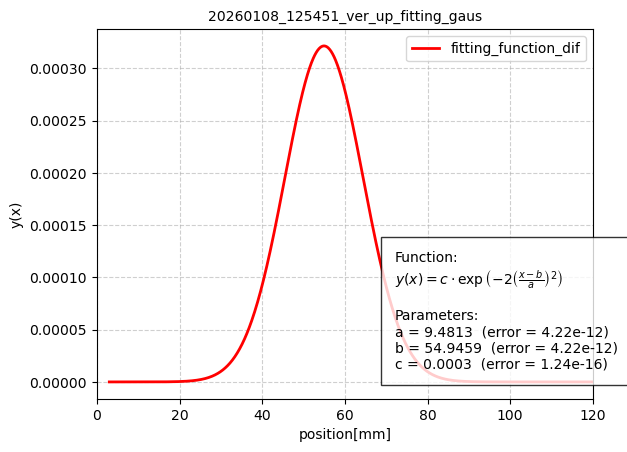

In [25]:
# --- 5. グラフを描画 ---
# グラフのサイズを指定
# plt.figure(figsize = (10, 6))
fig, ax = plt.subplots()

# 元のデータ点を青い点でプロット(散布図)
# plt.scatter(posi, power, label = 'measurement', color = 'blue')

# フィットした曲線を赤い線でプロット
# plt.plot(x_fit, y_fit_gaus, label = 'fitting_function_gaus', color = 'blue', linewidth = 2)
# plt.plot(x_fit_, y_dif_list, label = 'fitting_function_dif', color = 'red', linewidth = 2)
# plt.plot(x_fit_3, y_fit_gaus, label = 'fitting_function_gaus', color = 'blue', linewidth = 2)
plt.plot(x_fit_3, y_dif_list, label = 'fitting_function_dif', color = 'red', linewidth = 2)

# グラフのタイトルやラベルを設定
plt.title(basename + '_fitting_gaus', fontsize = 10)
plt.xlabel('position[mm]', fontsize = 10)
plt.ylabel('y(x)', fontsize = 10)
# ax[0].set_title(basename + '_fitting_gaus', fontsize = 15)
# ax[0].set_xlabel('position[mm]', fontsize = 15)
# ax[0].set_ylabel('dp/dx', fontsize = 15)

# 凡例を表示
# plt.legend()
plt.legend(fontsize = 10)

# グリッド線を表示
# plt.grid(True, linestyle = '--', alpha = 0.6)
plt.grid(True, linestyle = '--', alpha = 0.6)

formula_latex = r"$y(x) = c \cdot \exp \left( -2 \left( \frac{x-b}{a} \right)^2 \right)$"

param_text_2 = (
    f"a = {popt_2[0]:.4f}  (error = {np.sqrt(np.diag(pcov_2))[0]:.3})\n"
    f"b = {popt_2[1]:.4f}  (error = {np.sqrt(np.diag(pcov_2))[1]:.3})\n"
    f"c = {popt_2[2]:.4f}  (error = {np.sqrt(np.diag(pcov_2))[2]:.3})"
)

text_box_2 = f"Function:\n{formula_latex}\n\nParameters:\n{param_text_2}"

# グラフ上の任意の位置にテキストボックスを配置
# transform = ax.transAxesは、座標がグラフの左下(0, 0)から右上(1, 1)の相対座標であることを示す
# bboxはテキストを囲むボックスのスタイル設定
plt.text(
    0.6, # X座標(グラフの右端を1.0とする)
    0.4, # Y座標(グラフの上端を1.0とする)
    text_box_2,
    transform = ax.transAxes,
    fontsize = 10,
    verticalalignment = 'top',
    bbox = dict(boxstyle = 'square,pad = 1', facecolor = 'white', alpha = 0.8)
)

# plt.xlim([0.00, 120.00])
# plt.ylim([-0.00075, 0.00075])
plt.xlim([0.00, 120.00])
# ax[0].set_ylim([-0.001, 0.001])

# plt.savefig(f'{basename}_knife_edge_fitting_gaus.pdf', bbox_inches = 'tight', format = 'pdf', dpi = 100)